In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from fem_utils import * #con asterisco importa tutte le funzioni del pacchetto

# **Metodo degli Elementi Finiti per problemi parabolici**

Consideriamo il seguente problema tempo-dipendente nel caso monodimensionale, sul dominio $\Omega_T=\Omega\times[0,T)$, con $\Omega=(a,b)$:

Dati $\alpha:[0,T)\longrightarrow\mathbb{R}$, $\beta:[0,T)\longrightarrow\mathbb{R}$ e $u_0:\Omega\longrightarrow\mathbb{R}$, trovare $u:\Omega_T\longrightarrow\mathbb{R}$ tale che:

$$\begin{cases}
			\partial_t u - \partial_x(\gamma\partial_x u) = f, & \text{in}\ \Omega_T, \\
			u(a,t) = \alpha(t), & \text{per}\ t\in[0,T), \\
			u(b,t) = \beta(t), & \text{per}\ t\in[0,T), \\
			u(x,t=0) = u_0, & \text{in}\ \Omega\times\{0\}.
\end{cases}$$

Date condizioni al bordo di Dirichlet omogenee, la forma debole di questo problema è:

Trovare, $\forall t \in [0,T), \ u(t)\in V= H_0^1(\Omega)$ tale che

$$m(\partial_t u,v) + a(u,v) = F(v), \qquad \forall v\in V,$$

dove abbiamo definito:
$$m(u,v) = \int_a^b u v dx, \quad a(u,v) =\int_a^b \gamma \partial_x u \partial_x v dx, \quad F(v)=\int_a^b f v dx.$$

Fissato $t\in(0,T)$, la semi-discretizzazione in spazio si ottiene applicando il **Metodo degli Elementi Finiti**, scegliendo un sottospazio $V_h\subset V$ di dimensione $N_h$ finita e una sua base di funzioni linearmente indipendenti $\{\phi_j\}_{j=1}^{N_h}$. Il problema semi-discreto può quindi essere scritto in forma matriciale come segue:

Trovare, $\forall t\in [0,T), \ \mathbf{u}(t)\in\mathbb{R}^{N_h}$ tale che

$$
\mathbf{M}d_t\mathbf{u}(t)+\mathbf{A}\mathbf{u}(t) = \mathbf{f}(t),$$

dove
* $\mathbf{M}\in\mathbb{R}^{N_h\times N_h}:\ m_{ij}=m(\phi_j,\phi_i)$ è la matrice di massa degli Elementi Finiti;
* $\mathbf{A}\in\mathbb{R}^{N_h\times N_h}:\ a_{ij}=a(\phi_j,\phi_i)$ è la matrice di rigidezza;
* $\mathbf{f}(t)\in\mathbb{R}^{N_h}:\ \mathbf{F}(\phi_i)=[\mathbf{M}[f_{1}(t),\dots,f_{N_{h}}(t)]^{T}]_{i}$ è il vettore termine noto;
* $\mathbf{u}(t)\in\mathbb{R}^{N_h}:\ \mathbf{u}(t)=[u_1(t),\dots,u_{N_h}(t)]^T$.

Per il calcolo di $\mathbf{A}$ e $\mathbf{M}$ utilizziamo lo spazio degli Elementi Finiti

$$X_{h,0}^r = \{v_h\in\mathcal{C}([0,T]):\ v_h\big|_{[x_{i-1},x_i]}\in\mathbb{P}_r(x_{i-1},x_i)\}\cap\mathcal{C}([0,L]).$$

Il problema in tempo è quindi una ODE e può essere riscritto come segue:

$$
\begin{cases}
	d_t\mathbf{u}(t) =\tilde{\mathbf{f}}(t,\mathbf{u}(t))), & t\in[0,T), \\
	\mathbf{u}(0) =\mathbf{u}_0,
\end{cases}
$$

con termine noto $\tilde{\mathbf{f}}(t,\mathbf{u}(t))=-\mathbf{M}^{-1}\mathbf{A}\mathbf{u}(t)+\mathbf{M}^{-1}\mathbf{f}(t)$.

Dividiamo quindi $[0,T]$ in $N_t$ sottointervalli $(t_n, t_{n+1})$ tali che $t_0=0$, $t_{N_h}=T$, $t_n=n\Delta t$, con passo temporale $\Delta t=T/N_t$ e definiamo $\mathbf{u}^n=\mathbf{u}(t_n), \ n=0,\dots,N_t$.

Discretizziamo la derivata in tempo come:
$$		d_t \mathbf{u} \simeq \frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t}$$
e applichiamo il *$\theta$-metodo* per discretizzare la ODE:

$$		\frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t} = \theta\tilde{\mathbf{f}}^{n+1} + (1-\theta)\tilde{\mathbf{f}}^n, \qquad \theta\in[0,1].
$$

Sostituendo qui l'espressione di $\tilde{\mathbf{f}}$ otteniamo:
$$		\mathbf{M}\frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t}+\theta \mathbf{A}\mathbf{u}^{n+1} +(1-\theta)\mathbf{A}\mathbf{u}^n = \theta\mathbf{f}^{n+1}+(1-\theta)\mathbf{f}^n, \qquad \theta\in[0,1]. $$

Infine, il problema discreto diventa:

$\forall n=1,\dots,N_t$ trovare $\mathbf{u}^n\in\mathbb{R}^{N_h}$ tale che

$$
\begin{cases}
		\left(\frac{\mathbf{M}}{\Delta t} +\theta \mathbf{A}\right)\mathbf{u}^{n+1} = \left(\frac{\mathbf{M}}{\Delta t} - (1-\theta) \mathbf{A}\right)\mathbf{u}^{n} + \theta\mathbf{f}^{n+1}+(1-\theta)\mathbf{f}^n, & \forall n=1,\dots,N_t, \\
			\mathbf{u}^0 = \mathbf{u}_0.
\end{cases}
$$

A partire dall'istante $n=0$, possiamo ricavare iterativamente tutti i valori di $\mathbf{u}$ al passo successivo attraverso la risoluzione di un sistema lineare:

*Theta-metodo. Input: $\{\mathbf{f}^n\}_{n=1}^{N_t}$, $\mathbf{u}_0, \ \theta$. Output: $\mathbf{U}$*

1. Inizializzo $\mathbf{u}_{n}=\mathbf{u}_0$, $\mathbf{U}=[\mathbf{u}_n]$;
2.  For $n=1,\dots,N_t$

$\quad\quad$ 2.1. Calcolo $\mathbf{u}_{n+1}$ come soluzione del sistema lineare dato dal $theta$-metodo con parametro $\theta$;

$\quad\quad$ 2.2. Aggiorno $\mathbf{u}_{n}=\mathbf{u}_{n+1}$;

$\quad\quad$ 2.3. $\mathbf{U}=[\mathbf{U},\mathbf{u}_{n+1}]$.


Il $\theta$-metodo è incondizionatamente assolutamente stabile per $\theta\in[0.5,1]$ e condizionatamente assolutamente stabile per $\theta\in[0,0.5)$, con condizione di stabilità

$$		\Delta t\leq \frac{2}{\max|\lambda(\mathbf{M}^{-1}\mathbf{A})|}\approx ch^2,
$$

dove $\lambda(\mathbf{M}^{-1}\mathbf{A})$ indica gli autovalori della matrice $\mathbf{M}^{-1}\mathbf{A}$, da cui dipende la costante $c>0$.

# **Esercizio 1: equazione del calore**

Si consideri il seguente problema:

$$
\begin{cases}
  \partial_t u - \partial_{x} D \partial_x u = f(x), & \text{in}\ (0,L)\times [0,T), \\
  u(0,t)=u(L,t)=0, & \text{per}\ t\in [0,T), \\
  u(x,0)=u_0, & \text{in}\ (0,L),
\end{cases}
$$

con $D=1$, $L=1$, $T=1$,

$$ u_0(x)= \sin(\pi x), \qquad f(x,t)= (\pi^2-2)\sin(\pi x)e^{-2t}.$$

<mark>**Esercizio 1.1**<mark>

Si ricavi la formulazione debole e la formulazione algebrica dell'equazione, discretizzando in spazio usando il metodo FEM e in tempo il $\theta$-metodo.

**Soluzione**: si veda intro sopra. La ricavazione è identica qui.

<mark>**Esercizio 1.2**<mark>

Si implementi il $\theta$-metodo per la risoluzione del problema in tempo nella function `heat_solve`, definita come segue:

      heat_solve(grid, D, f, u0, T, dt, theta)
      ##
      ##
      return uh,th

dove in input abbiamo:

  * grid, griglia FEM 1D
  * $D$ il coefficiente di diffusione;
  * $f$ termine noto;
  * $u_0$ dato iniziale;
  * $T$ istante di tempo finale;
  * $dt$ passo temporale;
  * theta, parametro del theta-metodo;

ed in output

  * $uh$ matrice contentente i corrispondenti valori della soluzione $u_{i,n}=u_i(t^n)$, $i=1,\dots,N_h$, $n=1,\dots,N_T$;
  * $th$ vettore contenente gli istanti temporali: $t^n$, $n=0,\dots,N_t$.

In [5]:
def heat_solve(grid, D, f, u0, T, dt, theta):
  """"
  Input:
     grid    Grid object providing nodal coordinates in grid.nodes.
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    uh     (numpy.ndarray)-> matrix  Matrice contenente la soluzione approssimata del problema. 
                                      Uij approssima uh(dof_i, t_j): ogni colonna è un tempo fissato.
    th      (numpy.ndarray)-> vector Griglia temporale.
  """""
  # estrazione informazione dalla griglia/mesh
  h = grid.h
  nodes = grid.nodes
  Nele = grid.N

  # Griglia temporale  
  Nt = int((T-0)/dt)
  th = np.linspace(0,T,Nt+1)

  # Inizializzo la soluzione
  uh = np.zeros((len(nodes), len(th)))   #ho matrice con righe fatte da nodi e colonne fatte da istanti di tempo 

  # condizione iniziale
  u0h = fun2dof(grid, u0)
  uh[:, 0] = u0h #così sto mettendo nella prima colonna di uh la condiz iniziale

  # Boundary conditions (Dirichlet)
  dirichlet_nodes = [0, Nele]  
  dirichlet_values = [0,0] 

  # Costruzione del vettore dei valori al bordo
  bc_values = np.zeros(Nele + 1)
  bc_values[dirichlet_nodes] = dirichlet_values

  # Matrice di restrizione R
  keep_dof = np.ones(Nele + 1, dtype=bool)
  keep_dof[dirichlet_nodes] = False
  R = create_restriction(keep_dof)

  # Costruzione matrici di massa e diffusione
  M=mass(grid)
  A=diffusion(grid)
  A=D*A

  # Costruzioni matrici per il theta metodo
  G=(M/dt + theta*A)
  G_0= R@ G @ R.T

  # Ciclo temporale
  for n in range(len(th)-1):  #equivalente a range(Nt)

    # tempo dt e dt+1
    t_old=th[n]
    t_new=th[n+1]

    # termini noti al tempo dt e dt+1
    f_old=f(nodes,t_old) #perché la f è una lambda function che dipende sia da spazio che da tempo 
    f_new=f(nodes,t_new)

    # termine noto
    F_old= M @ f_old
    F_new =M @ f_new 

    ### Theta metodo ##
    g= (M/dt - (1-theta)*A) @uh[:, n] + theta * F_new + (1- theta)*F_old
    g_0= R @ (g - G @ bc_values)
    
    u_new_0 = np.linalg.solve(G_0, g_0)  # è la soluzione all'istante n+1 nei nodi interni

    # Ricostruzione della soluzione completa
    uh[:, n+1] = R.T @ u_new_0 + bc_values

  return uh, th

<mark>**Esercizio 1.3**<mark><br>

Risolvere il problema con i seguenti dati: $h=0.1$, $\Delta t = 0.01$ e $\theta = 0.5$.

In [6]:
# Dominio
a, b = 0, 1
h = 0.1

# generazione griglia
Nele= int((b-a)/h)
grid=Grid(a, b, Nele)
grid.compute_geometry()

# Dati del tempo
T = 1
dt = 0.01
# Coefficiente di diffusione
D = 1
# Parametro per il theta methodo
theta = 0.5
# Termine noto
f = lambda x, t: (np.pi*np.pi -2)*np.sin(np.pi*x)*np.exp(-2*t)
# Condizione iniziale
u0 = lambda x: np.sin(np.pi*x)

# Risoluzione equazione del calore
uh, th =heat_solve(grid, D, f, u0, T, dt, theta)


<mark>**Esercizio 1.4**<mark><br>

Data la soluzione esatta
</br></br>
$$
u_{\text{ex}}(x,t)=\sin(\pi x)e^{-2t}
$$
</br>

rappresentare su due grafici la soluzione esatta e la soluzione approssimata in $[0,T)$. Si sfrutti la funzione *xtplot*.

In [7]:
from fem_utils_plot import xtplot
help(xtplot)

Help on function xtplot in module fem_utils_plot:

xtplot(grid, u, t, plot_type='fade', color='b', linestyle='-', name_gif='solution_animation')
    Plot FEM solution in different formats.

    Args:
        grid (Grid): Finite element grid.
        u (np.ndarray): Solution matrix (space × time).
        t (np.ndarray): Time vector.
        plot_type (str): Plot type: "animation", "surface", "fade".
        color (str): Plot color.
        linestyle (str): Line style.
        name_gif (str): GIF filename base.

    Returns:
        None



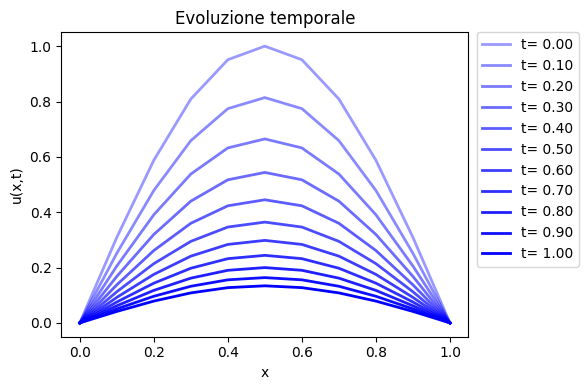

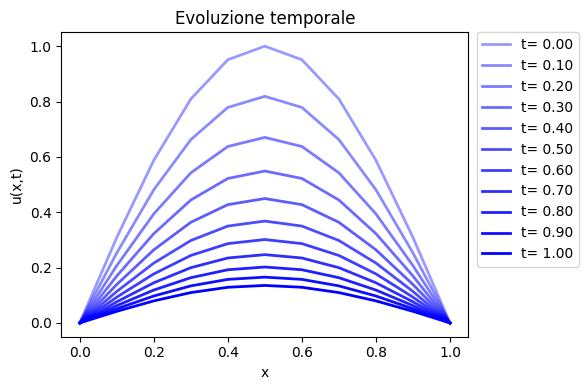

In [8]:
uex = lambda x,t: np.sin(np.pi*x)*np.exp(-2*t)

# Questo linee di codice servono per proiettare la soluzione esatta sullo spazio Vh e averla in un formato compatibile con quello richiesto da xtplot.
uex_t = np.zeros(uh.shape)  # Inizializzazione uex_t

# Soluzione approssimata
xtplot(grid, uh, th,'fade',color='b')
plt.show()

# soluzione esatta
for i in range(len(th)):
  uext = lambda x: uex(x, th[i])
  uex_t[:,i] = fun2dof(grid, uext)

xtplot(grid, uex_t, th,'fade')
plt.show()

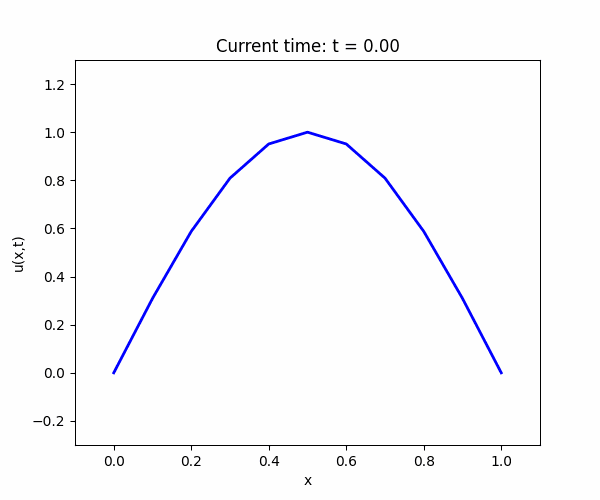

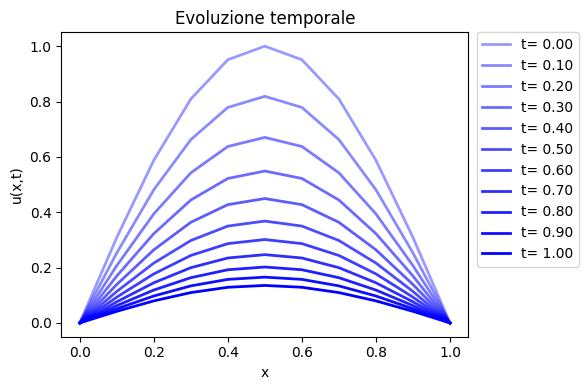

In [9]:
uex = lambda x,t: np.sin(np.pi*x)*np.exp(-2*t)

# Questo linee di codice servono per proiettare la soluzione esatta sullo spazio Vh e averla in un formato compatibile con quello richiesto da xtplot.
uex_t = np.zeros(uh.shape)  # Inizializzazione uex_t

# Soluzione approssimata
xtplot(grid, uh, th,'animation',color='b')
plt.show()

# soluzione esatta
for i in range(len(th)):
  uext = lambda x: uex(x, th[i])
  uex_t[:,i] = fun2dof(grid, uext)

xtplot(grid, uex_t, th,'fade')
plt.show()

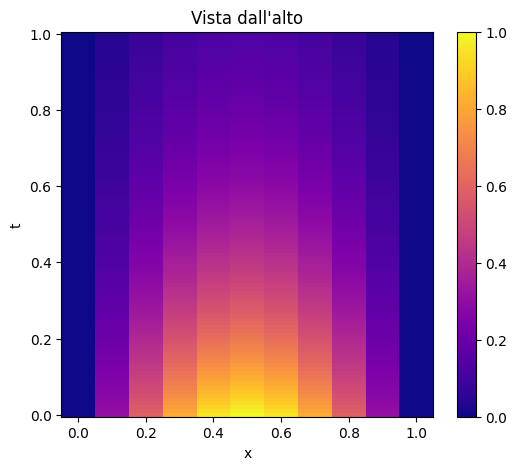

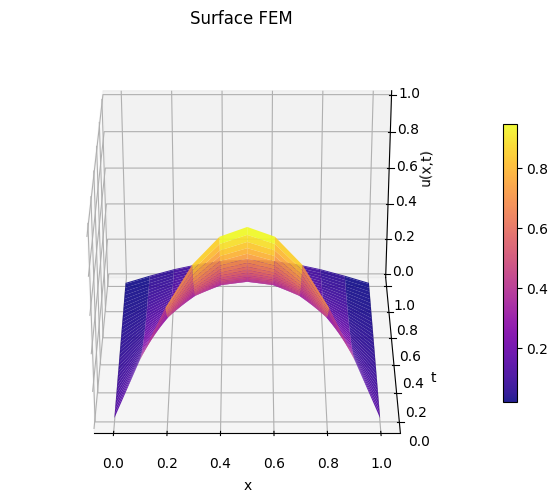

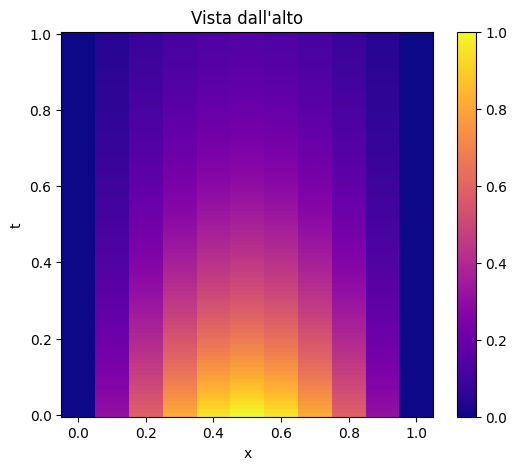

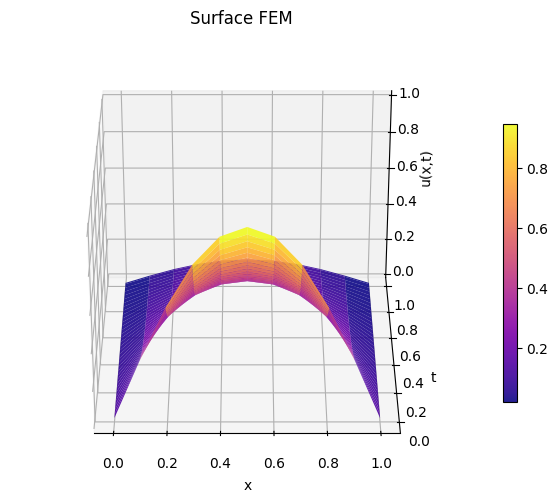

In [10]:
uex = lambda x,t: np.sin(np.pi*x)*np.exp(-2*t)

# Questo linee di codice servono per proiettare la soluzione esatta sullo spazio Vh e averla in un formato compatibile con quello richiesto da xtplot.
uex_t = np.zeros(uh.shape)  # Inizializzazione uex_t

# Soluzione approssimata
xtplot(grid, uh, th,'surface',color='b')
plt.show()

# soluzione esatta
for i in range(len(th)):
  uext = lambda x: uex(x, th[i])
  uex_t[:,i] = fun2dof(grid, uext)

xtplot(grid, uex_t, th,'surface')
plt.show()

In [ ]:
#dai grafici vediamo che la u si appiattisce nel tempo
#grafico surface abbiamo sugli assi u, x e t; 
#con animation abbiamo la u che si abbassa 
#mentre con fade abbiamo la animation con tutti gli istanti "screenshottati" insieme


<mark>**Esercizio 1.5**<mark><br>

Calcolare l'errore
</br></br>
$$
e(h,\Delta t):=\max_{t^{n}}\sqrt{\int_{0}^{L}|u_{ex}(x,t^{n})-u_{h}(x,t^{n})|^{2}dx}
$$
</br>

cioè il massimo, in tempo, degli errori in norma $L^2$, dove $u_{h}(x,t^{n}):=\sum_{i=1}^{N_{h}}u_{i,n}\phi_{i}(x)$.

In [13]:
#dobbiamo calcolare errore sia in spazio che in tempo
# generazione griglia
Nele = int((b - a) / h)
grid = Grid(a, b, Nele)
grid.compute_geometry()

err_t = []

# calcolo dell'errore
for i in range(len(th)): 
  #ad ogni istante calcolo l'errore e poi prenderò il massimo errore tra tutti gli istanti
  uex_t = lambda x: uex(x, th[i])
  uh_t = lambda x:np.interp(x, grid.nodes, uh[:,i])
  err_t.append(error_l2(grid, uex_t, uh_t))

err = max(err_t)

print(err)

0.008665354108311102


<mark>**Esercizio 1.6**<mark><br>

Risolvere il problema con $h=0.01$ e $\theta=1$ per $\Delta t$ che assume i valori $\{0.2,\ 0.1,\ 0.05,\ 0.025\}$ e rappresentare su un grafico l'andamento dell'errore $e(h,\Delta t)$ al variare di $\Delta t$. Cosa si osserva?

In [ ]:
...

plt.figure()
plt.loglog(dts, errors, '*-')
plt.loglog(dts, dts, '--')
plt.grid()
plt.xlabel('log(dt)')
plt.ylabel('log(err)')
plt.legend(['Errore con theta=1','y=dt'])
plt.show()

<mark>**Esercizio 1.7**<mark><br>

Risolvere nuovamente il problema con $h=0.01$ e $\theta=0$ per $\Delta t$ che assume i valori $\{0.2,\ 0.1,\ 0.05,\ 0.025\}$. Rappresentare su un grafico l'andamento dell'errore $e(h,\Delta t)$ al variare di $\Delta t$. Cosa si osserva?

In [ ]:
...

plt.figure()
plt.loglog(dts, errors)
plt.grid()
plt.xlabel('log(dt)')
plt.ylabel('log(err)')
plt.show()

# Esercizi per casa

## **Esercizio 2: problema diffusione-trasporto tempo dipendente**

Si consideri il problema di diffusione-trasporto tempo dipendente

$$
\begin{cases}
    \partial_t u = \alpha \partial_{xx} u - \beta \partial_x u + f(x), & \text{in}\ (0,L)\times [0,T), \\
    u(0,t)=0,\ u(L,t)=0, & \text{per}\ t\in [0,T), \\
    u(x,0)=u_0, & \text{in}\ (0,L)
\end{cases}
$$

con coefficienti costanti, $\alpha=10^{-2}$, $\beta=1$, $L=1$, $T=0.25$, forzante nulla, $f(x,t) \equiv 0$, e profilo iniziale

$$
u_0(x)= \begin{cases}
\cos^{4}(4\pi x - 2\pi) & 0.375\le x \le 0.625\\
0 & \text{altrimenti}.
\end{cases}
$$

<mark>**Esercizio 2.1**<mark>

Si ricavi la formulazione debole e la formulazione algebrica dell'equazione, discretizzata in spazio con il metodo FEM e in tempo con il $\theta$-metodo.

<mark>**Esercizio 2.2**<mark>

Si implementi la function `parabolic_solve`, che risolva il problema di diffusione-trasporto tempo dipendente, definita come segue:

    parabolic_solve(grid, \alpha, \beta, f, u0, T, dt, theta)
    ##
    ##
    return uh,th

dove in input abbiamo:

  * grid, griglia FEM 1D
  * $\alpha$, $\beta$ coefficiente di diffusione e trasporto, rispettivamente;
  * $f$ termine noto;
  * $u_0$ dato iniziale;
  * $T$ istante di tempo finale;
  * $dt$ passo temporale;
  * theta, parametro del theta-metodo;

ed in output

  * $uh$ matrice contentente i corrispondenti valori della soluzione $u_{i,n}=u_i(t^n)$, $i=1,\dots,N_h$, $n=1,\dots,N_T$;
  * $th$ vettore contenente gli istanti temporali: $t^n$, $n=0,\dots,N_t$.

In [ ]:
def parabolic_solve(grid, alpha,beta,f, u0,T,dt,theta):
  """"
  Input:surface
     grid    Grid object providing nodal coordinates in grid.nodes.
     alpha   (float)                 Coefficiente di diffusione (positivo).
     beta   (float)                  Velocità di trasporto.
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     T      (float)                  Tempo finale.
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    uh     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    th      (numpy.ndarray)-> vector Griglia temporale.
  """""
  ...

  return uh, th

<mark>**Esercizio 2.3**<mark><br>

Si testi la funzione *parabolic_solve* con $h =0.005$, $\Delta t = 0.001$ per diverse scelte del parametro $\theta$. Commentare i risultati.

In [ ]:
# Dati del problema
alpha, beta = 0.01, 1
L = 1 
a, b = 0, L

# Griglia FEM
h = 0.005
Nele = int((b - a) / h)
grid = Grid(a, b, Nele)
grid.compute_geometry()

# Tempo
T = 0.25
dt = 0.001

# Termine noto
f = lambda x,t : 0*x*t

# Dato iniziale
u0 = lambda x : np.cos(4*np.pi*x - 2*np.pi)**4 * (x <= 0.625) * (x >= 0.375)

<mark>**Esercizio 2.4**<mark><rb>

Si ripeta il punto precedente variando i valori di $\alpha>0$ e $\beta\in\mathbb{R}$. Come cambia la soluzione numerica?

<mark>**Esercizio 2.5**<mark><rb>

Si ripetano i test svolti nell'esercizio 2.4, utilizzando il metodo di Crank-Nicolson e Eulero esplicito. Si commentino i risultati.